# Image Classification Project — Computer Vision (AGH)

End-to-end **classical** pipeline (no neural networks):
load → preprocess → extract features → train/tune → evaluate on a held-out test set.

Core functions live in the `cvproject` package (`src/cvproject/*.py`); this
notebook only orchestrates them and shows results. Cells marked **TODO**
depend on functions that are still boilerplate — implement them in the package,
then re-run.

> Install once from the project root: `pip install -e ".[notebook]"`

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import cvproject
from cvproject import config, data, preprocessing, features, classification, metrics, viz
from cvproject.config import RNG

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(RNG)

print('cvproject', cvproject.__version__)
print('available datasets:', list(config.DATASETS))

cvproject 0.1.0
available datasets: ['potato_simple', 'potato_hard', 'apples_tomatoes']


In [ ]:
# The single switch: pick the dataset to work on.
cfg = config.get_config('apples_tomatoes')   # or 'potato_hard' / 'apples_tomatoes'
cfg['description']

'Fruit: apples vs tomatoes (391 imgs, pre-split train/test).'

## 2. Load & explore

Load the images, check class balance, and preview a few samples per class.

In [3]:
if cfg['presplit']:
    X_imgs, y_str, X_test_imgs, y_test_str = data.load_presplit(cfg)
else:
    X_imgs, y_str = data.load_dataset(cfg)
    X_test_imgs = y_test_str = None

print('loaded', len(X_imgs), 'images')
import collections
print('class counts:', collections.Counter(y_str))

apples_tomatoes/tomato: 100%|██████████| 43/43 [00:00<00:00, 3038.43it/s]

loaded 294 images
class counts: Counter({np.str_('apple'): 164, np.str_('tomato'): 130})


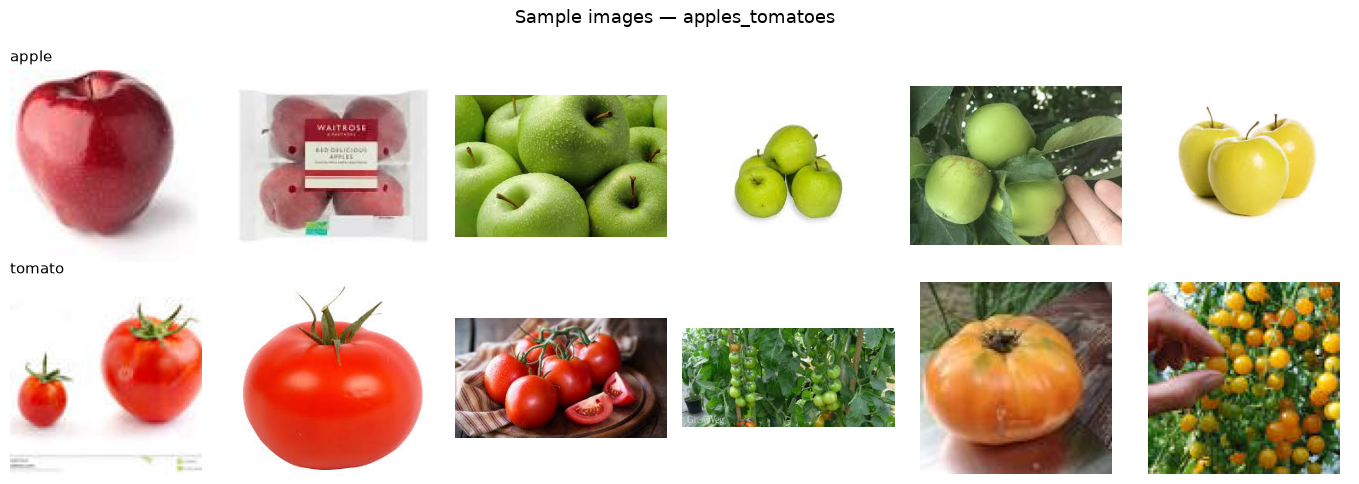

In [4]:
# Display helper (implemented): one row per class.
viz.show_class_samples(X_imgs, y_str, n_per_class=6,
                       suptitle=f"Sample images — {cfg['name']}")
plt.show()

## 3. Preprocessing

Artifact removal, brightness/colour enhancement, and segmentation of the object
from the background. **TODO:** tune the segmentation method/params for this dataset.

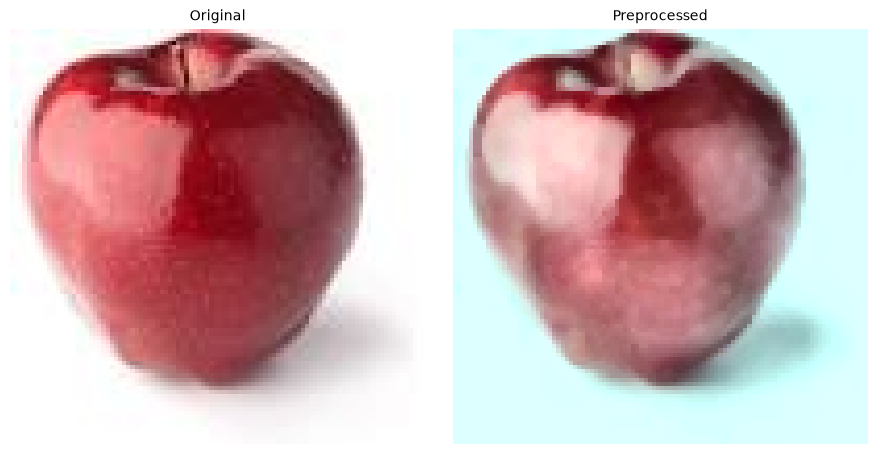

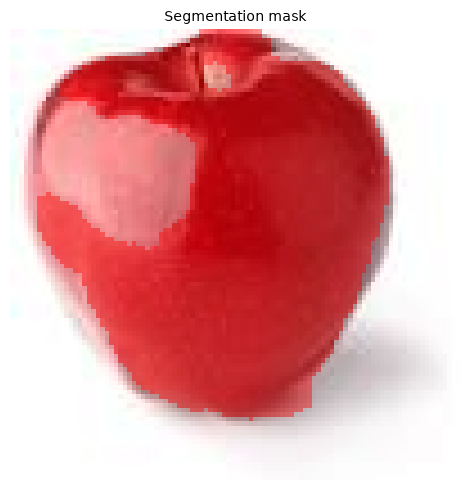

In [ ]:
# TODO: needs preprocessing.preprocess implemented.
sample = X_imgs[0]
processed, mask = preprocessing.preprocess(sample, cfg)

viz.show_pair(sample, processed, titles=('Original', 'Preprocessed'))
plt.show()
if mask is not None:
    viz.show_mask_overlay(sample, mask, title='Segmentation mask')
    plt.show()

In [ ]:
# TODO: preprocess the whole dataset (keep masks for masked feature extraction).
proc_imgs, masks = [], []
for img in X_imgs:
    p, m = preprocessing.preprocess(img, cfg)
    proc_imgs.append(p)
    masks.append(m)

## 4. Feature extraction

Texture (GLCM), colour statistics and shape descriptors. **TODO:** decide which
feature families help most for this dataset (`use=...`).

In [ ]:
# TODO: needs features.build_feature_matrix implemented.
USE = ('glcm', 'color', 'shape')
X, feat_names = features.build_feature_matrix(proc_imgs, masks=masks, use=USE)
print('feature matrix:', X.shape, '|', len(feat_names), 'features')

features: 100%|██████████| 294/294 [00:01<00:00, 273.99it/s]

feature matrix: (294, 85) | 85 features


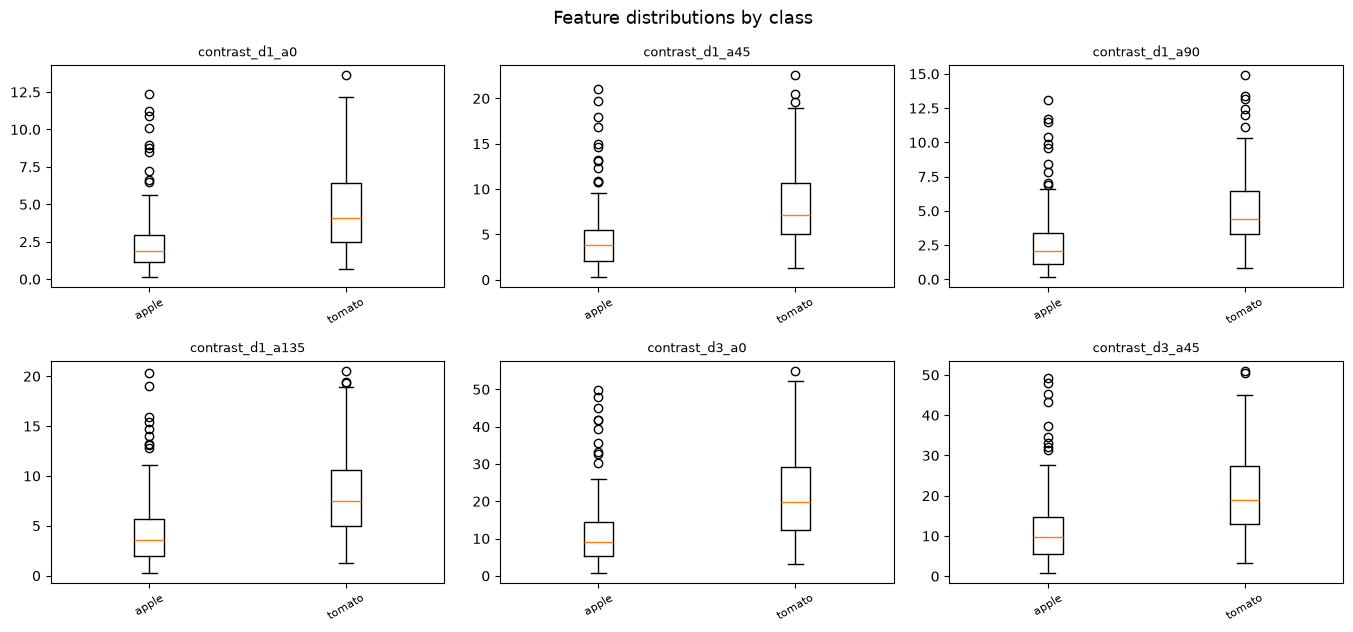

In [8]:
# Per-class feature distributions (implemented helper).
viz.plot_feature_distributions(X, y_str, feat_names, max_features=6, suptitle='Feature distributions by class')
plt.show()

## 5. Train / validation / test split

Honour the dataset's pre-split test set when present, otherwise make a stratified
three-way split.

In [ ]:
# TODO: needs data.encode_labels / make_splits implemented.
y, le = data.encode_labels(y_str)

presplit = None
if cfg['presplit']:
    # TODO: extract features for the pre-split test images too, then encode.
    proc_test = [preprocessing.preprocess(im, cfg)[0] for im in X_test_imgs]
    masks_test = [preprocessing.preprocess(im, cfg)[1] for im in X_test_imgs]
    X_test, _ = features.build_feature_matrix(proc_test, masks=masks_test, use=USE)
    y_test = le.transform(y_test_str)
    presplit = (X_test, y_test)

splits = data.make_splits(X, y, val_size=0.2, test_size=0.2, presplit=presplit)
for k, v in splits.items():
    print(k, np.asarray(v).shape)

features: 100%|██████████| 97/97 [00:00<00:00, 282.66it/s]

X_train (235, 85)
y_train (235,)
X_val (59, 85)
y_val (59,)
X_test (97, 85)
y_test (97,)


## 6. Train & tune (on train/validation)

Each model is a `StandardScaler` + classifier pipeline. **TODO:** fill in
`classification.PARAM_GRIDS` and tune on the training set.

In [ ]:
# TODO: needs classification.build_models / tune implemented.
models = classification.build_models()

tuned = {}
for name, model in models.items():
    grid = classification.PARAM_GRIDS.get(name, {})
    search = classification.tune(model, grid, splits['X_train'], splits['y_train'])
    tuned[name] = search.best_estimator_
    print(f'{name:15s} best CV score = {search.best_score_:.4f}  {search.best_params_}')

svm             best CV score = 0.7993  {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
decision_tree   best CV score = 0.7055  {'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1}
random_forest   best CV score = 0.7892  {'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__n_estimators': 200}
knn             best CV score = 0.7843  {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
logreg          best CV score = 0.7889  {'clf__C': 0.1}


## 7. Evaluate on the held-out test set

Compare models, then inspect the best one's confusion matrix. **TODO (markdown):**
write the critical analysis of the metrics for the report.

In [ ]:
# TODO: needs classification.predict_all / metrics.compare_models implemented.
preds = classification.predict_all(tuned, splits['X_test'])
comparison = metrics.compare_models(preds, splits['y_test'])
comparison

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
knn,0.742268,0.739065,0.740095,0.739499,0.742980,0.742268,0.742545
svm,0.742268,0.743852,0.730620,0.733076,0.743155,0.742268,0.738694
logreg,0.731959,0.728467,0.728467,0.728467,0.731959,0.731959,0.731959
random_forest,0.711340,0.708223,0.702842,0.704268,0.710028,0.711340,0.709454
decision_tree,0.659794,0.654773,0.649440,0.650279,0.657403,0.659794,0.656820


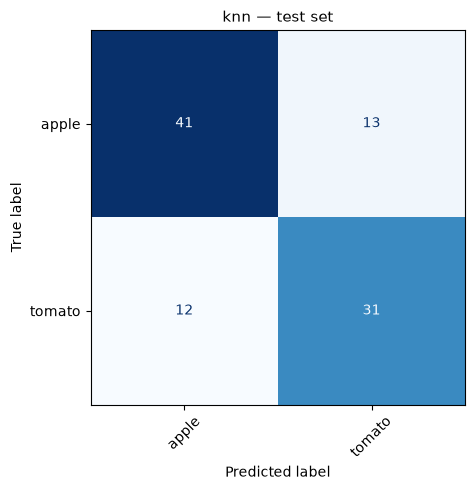

              precision    recall  f1-score   support

       apple       0.77      0.76      0.77        54
      tomato       0.70      0.72      0.71        43

    accuracy                           0.74        97
   macro avg       0.74      0.74      0.74        97
weighted avg       0.74      0.74      0.74        97



In [ ]:
# Confusion matrix of the best model (top of the sorted comparison table).
best_name = comparison.index[0]
cm = metrics.confusion(splits['y_test'], preds[best_name])
viz.plot_confusion_matrix(cm, le.classes_, normalize=False, title=f'{best_name} — test set')
plt.show()

print(metrics.report(splits['y_test'], preds[best_name], target_names=list(le.classes_)))

## 8. Conclusions

_TODO: summarise — which features mattered, which classifier won and why,
where it fails (confusions), and any preprocessing/parameter choices worth
noting for the presentation & documentation._